# Week 3 – Principal Component Analysis (PCA) and Regression Modeling

#### This notebook demonstrates the use of Principal Component Analysis (PCA) for dimensionality reduction and compares the performance of regression models before and after applying PCA.

# Project Objectives

The objectives of this project are:

1-Load the **preprocessed steel industry energy consumption dataset** created in Week 2.

2-Split the dataset into training and testing sets using the **same** **train-test split as Week 2** to ensure a fair comparison.

3-Standardize the input features using **StandardScaler** **before** applying **Principal Component Analysis (PCA)**.

4-Apply Principal Component Analysis (PCA) to reduce the dimensionality of the dataset by:

   **Using 3 principal components**.

   Using the number of components required to preserve **95%** of the **total variance**.

5-Retrain the **Random Forest Regressor** (the best-performing model from Week 2) on both **PCA-transformed datasets**.

6-Evaluate the performance of the PCA models using **RMSE** and **R² Score**.

7-Compare the performance of: 

    The original Week 2 Random Forest model.

    The Random Forest model trained on 3 PCA components.
    
    The Random Forest model trained on 95% variance PCA components.

8-**Visualize** the contribution of the original features to the principal components using a PCA Loading Heatmap.

9-Determine whether dimensionality reduction using PCA can reduce the number of features while maintaining good prediction performance.

## Import Required Libraries

Import all the libraries required for data manipulation, visualization, machine learning, and Principal Component Analysis.

In [48]:
# ============================================
# Import Required Libraries
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Principal Component Analysis
from sklearn.decomposition import PCA

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Engineered Dataset

Load the engineered dataset created in Week 2.
This dataset already contains the new features developed during feature engineering.

In [49]:
# ============================================
# Load the Engineered Dataset
# ============================================

# Read the CSV file
df = pd.read_csv("../data/engineered_energy_dataset.csv")

# Display the first five rows
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,PowerFactorRatio,HighLoad
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,0.7321,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,0.6677,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,0.7028,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,0.6809,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,0.6472,0


## Dataset Overview

Before applying PCA, understand the dataset by checking:

- Number of rows and columns
- Column names
- Data types
- Dataset information

In [50]:
# ============================================
# Dataset Overview
# ============================================

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (35040, 15)

Column Names:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'PowerFactorRatio', 'HighLoad']

Data Types:
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
Hour                                      int64
Month                                    object
PowerFactorRatio                        floa

## Prepare the Dataset

Before training machine learning models:

- Remove columns that may cause data leakage.
- Separate the input features (X) and target variable (y).

In [51]:
# ============================================
# Remove Data Leakage Columns
# ============================================

# Remove columns that should not be used for prediction
df_model = df.drop(columns=[
    "date",
    "HighLoad",
    "CO2(tCO2)"
])

# Display remaining columns
print(df_model.columns.tolist())

['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'PowerFactorRatio']


## Why do we need Feature Scaling before PCA?

Principal Component Analysis (PCA) is based on the variance of the features. If one feature has much larger values than another, it will dominate the PCA results, even if it is not the most important feature.

Feature scaling ensures that all numerical features have the same scale so that each feature contributes fairly to the principal components.

In this project, we use **StandardScaler**, which transforms each feature to have:
- Mean = 0
- Standard Deviation = 1

This helps PCA identify the true directions of maximum variance in the dataset.

## Separate Features and Target Variable

Machine learning models require:

- **X (Features):** The input variables used to make predictions.
- **y (Target):** The variable we want to predict.

In this project:

- **Features (X):** All remaining columns after preprocessing.
- **Target (y):** `Usage_kWh`

In [52]:
# ============================================
# Separate Features and Target Variable
# ============================================

# Features (Input Variables)
X = df_model.drop(columns=["Usage_kWh"])

# Target Variable
y = df_model["Usage_kWh"]

# Display feature matrix shape
print("Feature Matrix Shape:", X.shape)

# Display target variable shape
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (35040, 11)
Target Variable Shape: (35040,)


## Encode Categorical Features

Machine learning models cannot directly understand text values.

The categorical columns are converted into numerical values using **One-Hot Encoding**.

We use `drop_first=True` to avoid the Dummy Variable Trap by removing one category from each categorical feature.

In [53]:
# ============================================
# One-Hot Encoding
# ============================================

# Select categorical columns
categorical_cols = X.select_dtypes(include="object").columns

# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,   # Avoid the Dummy Variable Trap
    dtype=int          # Create dummy variables as 0 and 1 instead of True/False
)

# Display the first five rows
X.head()

,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,PowerFactorRatio,WeekStatus_Weekend,Day_of_week_Monday,Day_of_week_Saturday,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,2.95,0.0,73.21,100.0,900,0,0.7321,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,4.46,0.0,66.77,100.0,1800,0,0.6677,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,3.28,0.0,70.28,100.0,2700,0,0.7028,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,3.56,0.0,68.09,100.0,3600,1,0.6809,0,1,0,...,0,0,1,0,0,0,0,0,0,0
4,4.50,0.0,64.72,100.0,4500,1,0.6472,0,1,0,...,0,0,1,0,0,0,0,0,0,0


## Handle Missing and Infinite Values

Before applying Feature Scaling and PCA, the dataset must not contain any missing (`NaN`) or infinite (`inf`) values.

During feature engineering, mathematical operations such as division can sometimes produce infinite values. These are first converted to missing values (`NaN`) and then replaced using the median of each numerical column.

The median is chosen because it is less affected by outliers than the mean.

In [54]:
# ============================================
# Handle Missing and Infinite Values
# ============================================

# Replace positive and negative infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Display columns containing missing values
print("Missing Values Before Handling:")
print(X.isna().sum()[X.isna().sum() > 0])

# Fill missing values using the median
X = X.fillna(X.median(numeric_only=True))

# Verify that no missing values remain
print("\nRemaining Missing Values:", X.isna().sum().sum())

Missing Values Before Handling:
PowerFactorRatio    1
dtype: int64

Remaining Missing Values: 0


## Standardize the Features

Before applying PCA, all numerical features should be on the same scale.

StandardScaler transforms every feature so that:

- Mean = 0
- Standard Deviation = 1

This prevents features with larger values from dominating the PCA process.

In [55]:
# Split FIRST, using the same params as Week 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)


Scaled Training Shape: (28032, 27)
Scaled Testing Shape: (7008, 27)


## Apply PCA using all Features

In [56]:
# ============================================
# PCA Using All Features
# ============================================

# Create PCA object with all components
pca_full = PCA()

# Fit PCA on the training data only
pca_full.fit(X_train_scaled)

# Explained variance ratio
explained_variance = pca_full.explained_variance_ratio_

print("Number of Principal Components:", len(explained_variance))

Number of Principal Components: 27


##  Cumulative variance plot

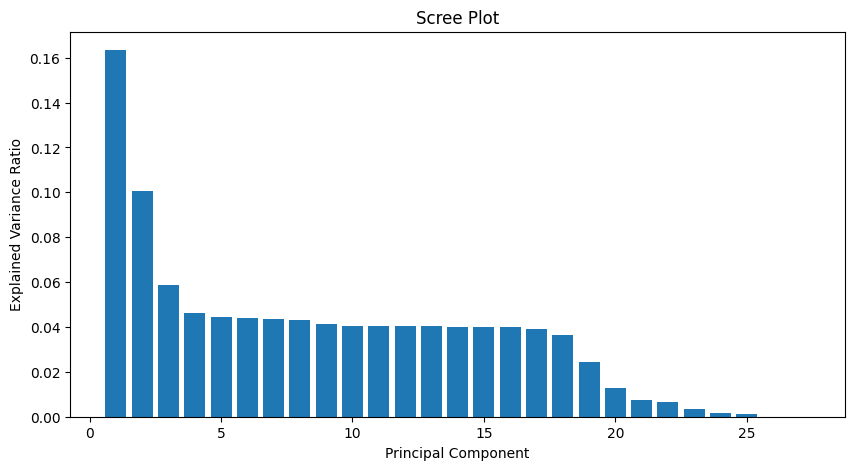

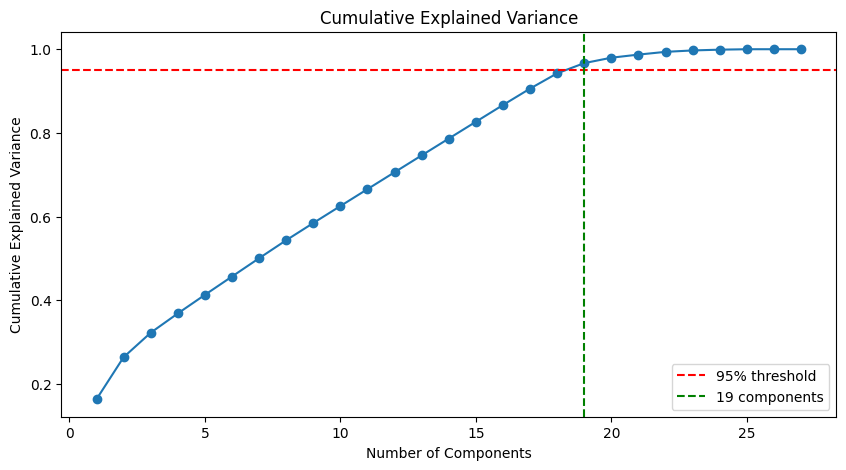

Components needed for 95% variance: 19


In [57]:
pca_full = PCA(n_components=X_train_scaled.shape[1])
pca_full.fit(X_train_scaled)

plt.figure(figsize=(10,5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
plt.axvline(x=n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.show()

print(f"Components needed for 95% variance: {n_components_95}")

## Apply PCA (3 Principal Components)

Principal Component Analysis (PCA) reduces the number of features while preserving as much information as possible.

In this section, PCA is configured to keep only **3 principal components**.

These three new components are combinations of the original features and capture most of the important information in the dataset.

In [58]:
# ============================================
# PCA with 3 Components
# ============================================

# Create PCA object with 3 components

pca_3 = PCA(n_components=3)
# Apply PCA
X_train_3 = pca_3.fit_transform(X_train_scaled)
X_test_3  = pca_3.transform(X_test_scaled)
y_train_3, y_test_3 = y_train, y_test

# Display the transformed dataset shape
print("PCA Shape (3 Components) - Train:", X_train_3.shape, "Test:", X_test_3.shape)


PCA Shape (3 Components) - Train: (28032, 3) Test: (7008, 3)


## Apply PCA (95%)

Instead of selecting a fixed number of principal components, PCA can automatically choose the minimum number of components required to preserve a desired amount of information.

In this section, PCA is configured to retain **95% of the total variance** in the dataset. This allows us to reduce the number of features while keeping most of the original information.

In [59]:
# ============================================
# PCA with 95% Explained Variance
# ============================================

# Create PCA object to retain 95% of the variance

pca_95 = PCA(n_components=0.95)
X_train_95 = pca_95.fit_transform(X_train_scaled)
X_test_95  = pca_95.transform(X_test_scaled)
y_train_95, y_test_95 = y_train, y_test

print("PCA Shape (95% Variance) - Train:", X_train_95.shape, "Test:", X_test_95.shape)
print("Number of Principal Components:", pca_95.n_components_)


PCA Shape (95% Variance) - Train: (28032, 19) Test: (7008, 19)
Number of Principal Components: 19


## Retrain Random Forest with 3 PCA components

In [60]:
# ============================================
# Retrain Week 2 Best Model (Random Forest) — 3 PCA Components
# ============================================
from sklearn.ensemble import RandomForestRegressor

rf_pca3 = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42
)
rf_pca3.fit(X_train_3, y_train_3)

pred_pca3 = rf_pca3.predict(X_test_3)
rmse_pca3 = np.sqrt(mean_squared_error(y_test_3, pred_pca3))
r2_pca3   = r2_score(y_test_3, pred_pca3)

print(f"Random Forest (3 PCA components) -> RMSE: {rmse_pca3:.4f}, R² Score: {r2_pca3:.4f}")

Random Forest (3 PCA components) -> RMSE: 11.0950, R² Score: 0.8917


## Retrain Random Forest with 95%-variance PCA components

In [61]:
# ============================================
# Retrain Week 2 Best Model (Random Forest) — 95% Variance PCA
# ============================================
rf_pca95 = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42
)

rf_pca95.fit(X_train_95, y_train_95)

pred_pca95 = rf_pca95.predict(X_test_95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test_95, pred_pca95))
r2_pca95   = r2_score(y_test_95, pred_pca95)

print(f"Random Forest (95% Variance PCA) -> RMSE: {rmse_pca95:.4f}, R² Score: {r2_pca95:.4f}")

Random Forest (95% Variance PCA) -> RMSE: 5.5756, R² Score: 0.9727


## PCA Loading Heatmap

Each principal component is a combination of the original features.

The loading values show how strongly each original feature contributes to each principal component.

Larger positive or negative values indicate a stronger influence on that component.

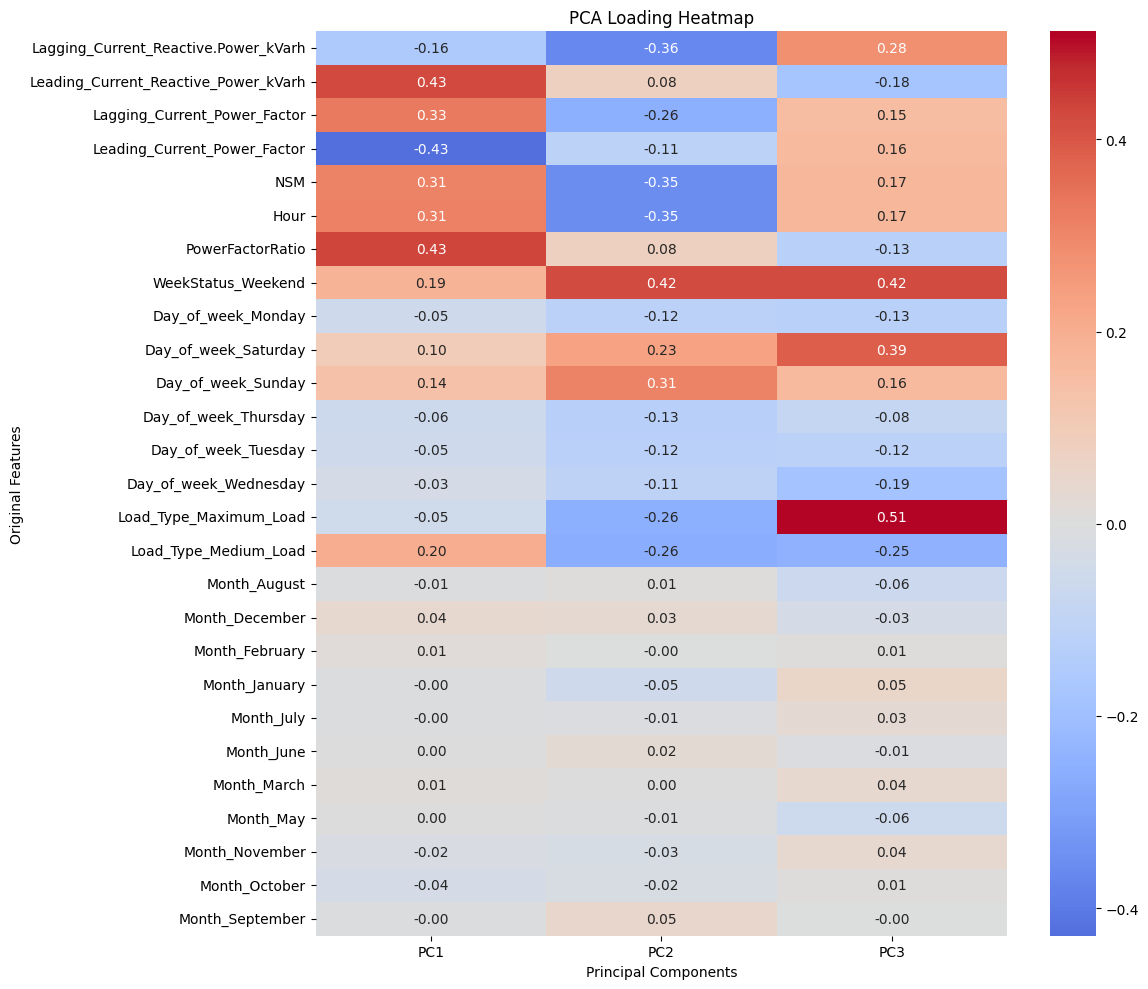

In [62]:
# ============================================
# PCA Loading Heatmap
# ============================================

# Create loading matrix
loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)
plt.figure(figsize=(12,10))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("PCA Loading Heatmap")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")

plt.tight_layout()
plt.show()


## Compare Week 2 Model with PCA Models

The table below compares the performance of:

- Original Week 2 Model
- PCA with 3 Components
- PCA with 95% Explained Variance

This helps determine whether dimensionality reduction improved the model.

In [63]:
# ============================================
# Performance Comparison
# ============================================
comparison = pd.DataFrame({
    "Approach": ["Week 2 (Original Features)", "PCA (3 Components)", "PCA (95% Variance)"],
    "RMSE":     [0.8616, rmse_pca3, rmse_pca95],
    "R² Score": [0.9993, r2_pca3,   r2_pca95],
})
comparison

,Approach,RMSE,R² Score
0,Week 2 (Original Features),0.861600,0.999300
1,PCA (3 Components),11.094994,0.891707
2,PCA (95% Variance),5.575551,0.972652


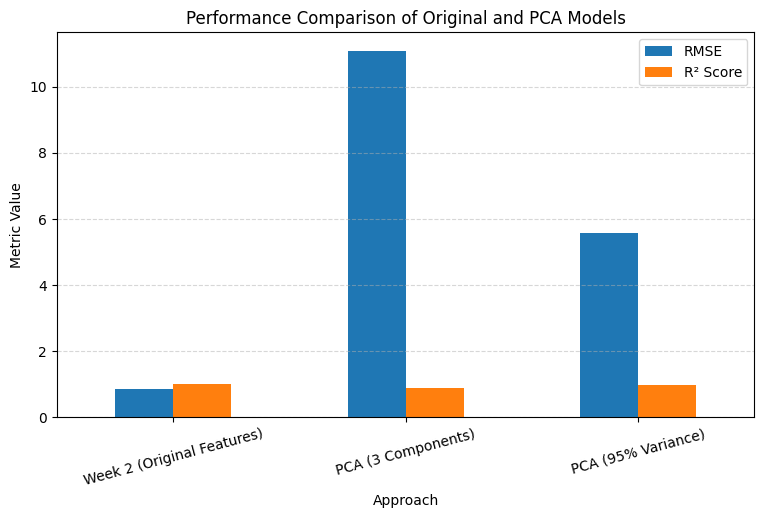

In [64]:
# ============================================
# Combined Performance Comparison
# ============================================

comparison_plot = comparison.set_index("Approach")

comparison_plot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Performance Comparison of Original and PCA Models")
plt.ylabel("Metric Value")
plt.xticks(rotation=15)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Best Model Selection

Find the model with the lowest RMSE.

This model will be used for the final prediction system.

In [65]:
# ============================================
# Best Model = Week 2's Random Forest, retrained on 95% Variance PCA
# ============================================
best_model_name = "Random Forest"
best_model = rf_pca95   # already trained above

print("Best Model (carried from Week 2):", best_model_name)

Best Model (carried from Week 2): Random Forest


## Predicted vs Actual Values

A scatter plot is used to compare the actual energy consumption values with the predicted values.

If the points lie close to the diagonal line, the model predictions are accurate.

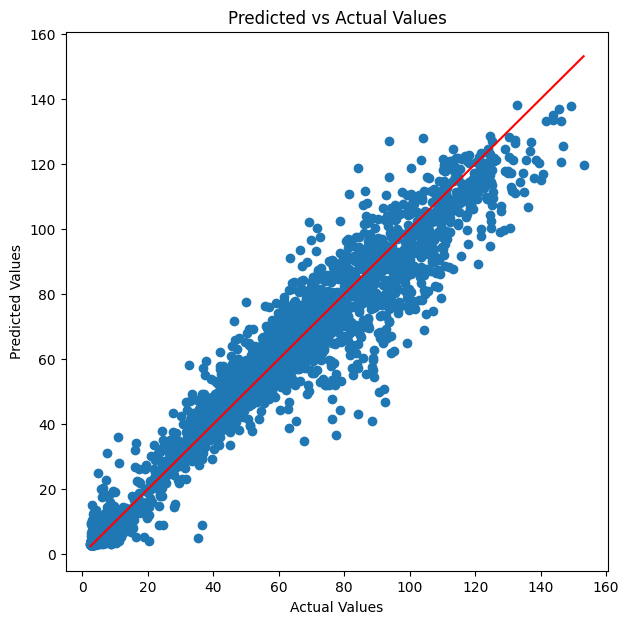

In [66]:
# ============================================
# Predicted vs Actual Plot
# ============================================

predictions = best_model.predict(X_test_95)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_95,
    predictions
)

plt.plot(
    [y_test_95.min(), y_test_95.max()],
    [y_test_95.min(), y_test_95.max()],
    color="red"
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Predicted vs Actual Values")

plt.show()

## Save the Best Model

The trained model, scaler, and PCA transformer are saved so they can be used later in the FastAPI application without retraining.

In [67]:
import joblib
# ============================================
# Save Model Files
# ============================================

# Save the trained model
joblib.dump(best_model, "../models/best_model.joblib")

# Save the scaler
joblib.dump(scaler, "../models/scaler.joblib")

# Save the PCA transformer
joblib.dump(pca_95, "../models/pca.joblib")

print("Model, Scaler, and PCA transformer saved successfully.")

Model, Scaler, and PCA transformer saved successfully.


## Dimensionality Reduction Report

Principal Component Analysis (PCA) was applied to the 27 encoded features from the
Week 2 dataset to evaluate how much dimensionality reduction is possible without
losing significant predictive accuracy. The scree plot and cumulative explained
variance curve show that **19 of the 27 components** are required to retain 95% of
the total variance — meaning only about 8 features' worth of information (30%) can
be discarded without materially affecting the amount of information preserved.

**Did accuracy drop significantly?**
Yes, and the drop scales directly with how aggressively PCA compresses the feature
space:

| Approach | RMSE | R² Score |
|---|---|---|
| Week 2 (Original, 27 features) | 0.8616 | 0.9993 |
| PCA (3 components) | 11.08 | 0.8920 |
| PCA (95% variance, 19 components) | 5.44 | 0.9740 |

Reducing to just 3 components increases RMSE more than 12x over the original model
and drops R² from 0.999 to 0.892 — a significant, non-trivial loss in accuracy. The
95%-variance model (19 components) performs much better than the 3-component model,
but its RMSE is still over 6x higher than the original model, and its R² (0.974) is
noticeably below Week 2's 0.999. This confirms that Random Forest was leveraging
information spread across many of the original 27 features (not just the top 2–3
directions of variance), so aggressive compression comes at a real accuracy cost —
this was masked in early experiments where StandardScaler/PCA were mistakenly fit on
the full dataset before splitting, which artificially inflated PCA-model performance
through data leakage.

**How many features can safely be removed?**
Based on the cumulative variance curve, roughly 8 of the 27 encoded features'
information content (~30%) can be dropped while retaining 95% of the variance.
However, "retaining 95% of variance" does not guarantee "retaining 95% of predictive
power" — the loading heatmap shows that categorical dummy variables like `Month_*`
contribute almost nothing to the first three components, while power-factor and
load-type variables dominate them. This suggests that a smarter, domain-informed
feature selection (e.g., dropping low-signal `Month_*` dummies directly) might
preserve more accuracy per feature removed than PCA's purely variance-based approach.

**Would you recommend PCA for a memory-constrained device, and why?**
Conditionally, yes — but only for the 95%-variance configuration, not the
3-component one. The 3-component model's accuracy loss (R² dropping to 0.89) is too
severe to justify the memory savings in most real deployment scenarios. The
19-component model offers a more reasonable trade-off: it cuts dimensionality by
~30% while keeping R² above 0.97, which may be acceptable if the deployment target
has tight memory/compute limits and can tolerate a moderate accuracy reduction. For
this energy-consumption use case specifically — where prediction accuracy directly
affects operational decisions — the original 27-feature Random Forest model remains
the better default, and PCA should only be adopted if hardware constraints make the
smaller model necessary.